In [7]:
import pickle 

filepath = "../../old/benign_22_12/graph_construction/graph.pkl"
with open(filepath, 'rb') as f:
    graph = pickle.load(f)
graph

In [12]:
train_nodes = [
    node for node, attr in graph.nodes(data=True)
    if attr["packet_id"] <= 100
]
graph_train = graph.subgraph(train_nodes)

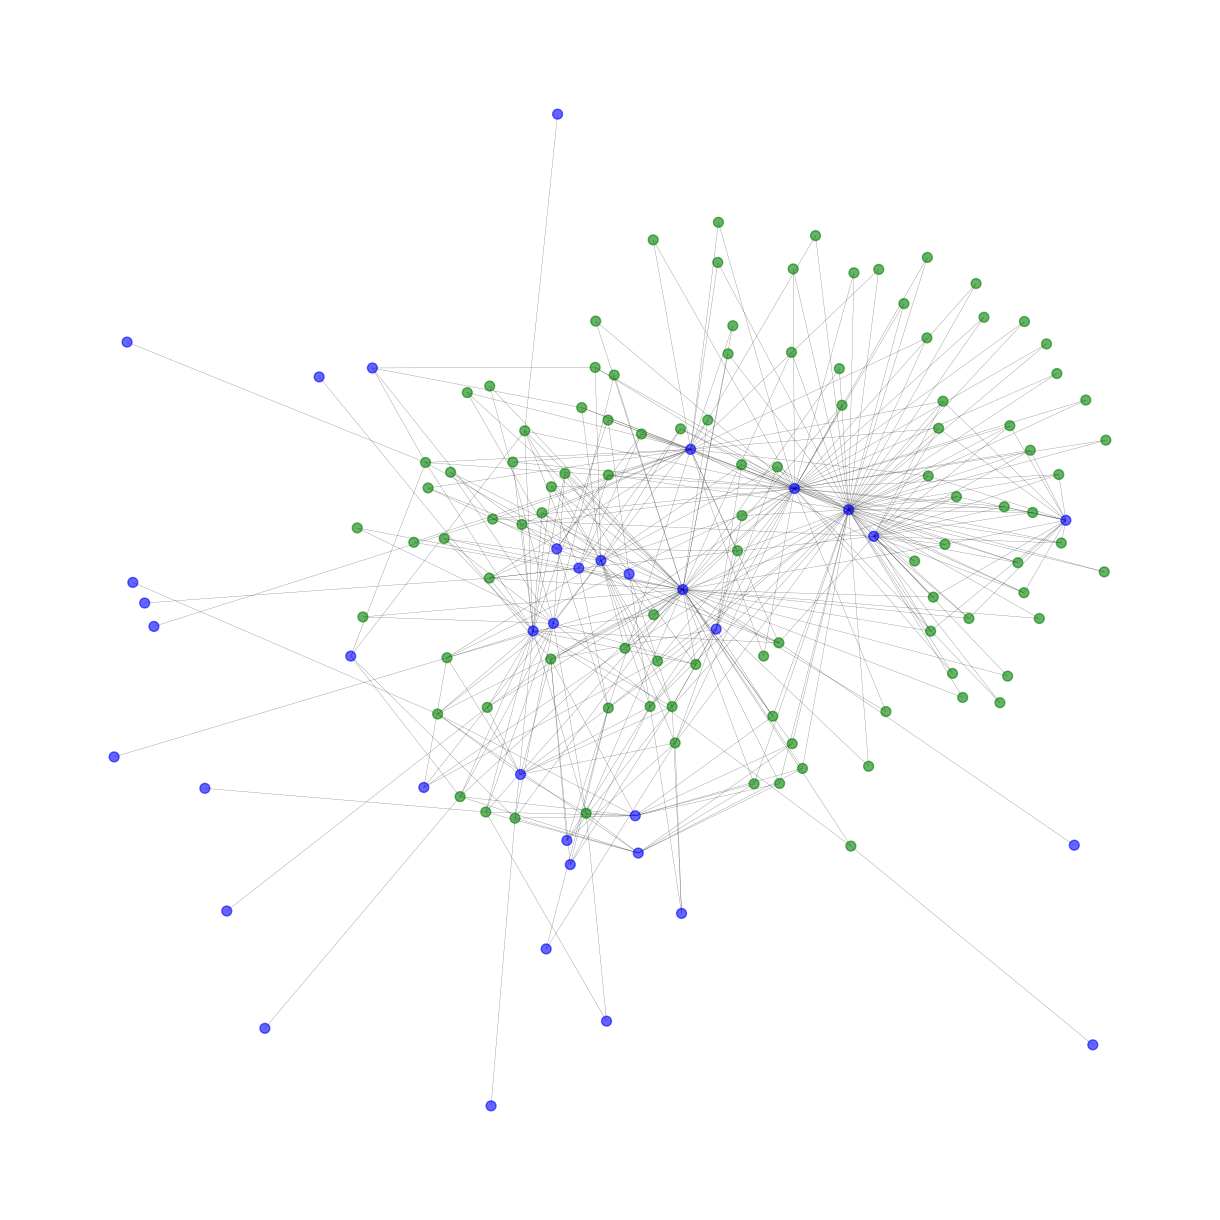

In [25]:
import networkx as nx
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))
pos = nx.spring_layout(graph_train, k=0.1, iterations=20)
node_colors = ['green' if attr["node_type"]==1 else 'blue' for j,attr in graph_train.nodes(data=True)]
nx.draw(
    graph_train,
    pos,
    node_size=50,
    node_color=node_colors,
    alpha=0.6,
    width=0.2
)
plt.show()


In [ ]:
import pickle 

filepath = "../../data/model_input/val.pkl"
with open(filepath, 'rb') as f:
    loader = pickle.load(f)
loader

In [3]:
from torch_geometric.loader import NeighborLoader

neighbor_loader = NeighborLoader(loader, [30, 30], loader.is_central, batch_size=32, shuffle=False)
neighbor_loader

NeighborLoader()

In [20]:
i =0
for batch in neighbor_loader:
    print(len(batch.n_id))
    i+=1
    if i==10:
        break

63
86
96
78
74
107
98
107
101
117


In [89]:
batch

Data(x=[63, 713], edge_index=[2, 203], edge_attr=[203, 713], packet_id=[63], is_central=[63], is_attack=[63], n_id=[63], e_id=[203], num_sampled_nodes=[3], num_sampled_edges=[2], input_id=[32], batch_size=32)

In [84]:
for x in neighbor_loader:
    print(x)
    break

Data(x=[63, 713], edge_index=[2, 203], edge_attr=[203, 713], packet_id=[63], is_central=[63], is_attack=[63], n_id=[63], e_id=[203], num_sampled_nodes=[3], num_sampled_edges=[2], input_id=[32], batch_size=32)


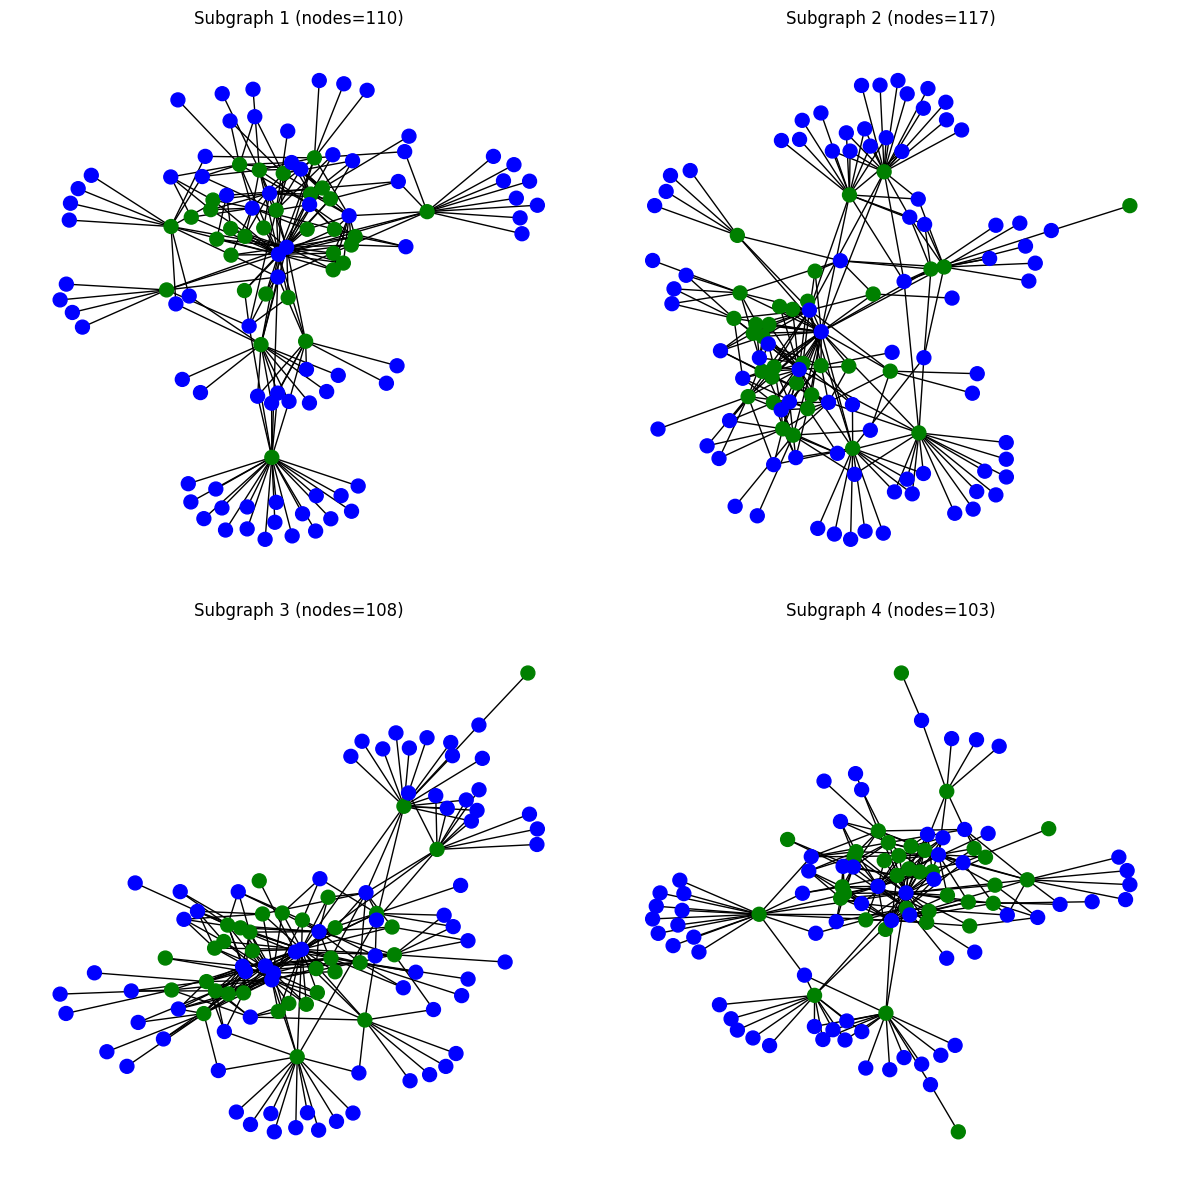

In [11]:
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx

subgraphs = []
for batch in neighbor_loader:
    subgraphs.append(batch)
    if len(subgraphs) == 4:
        break

plt.figure(figsize=(12, 12))

for i, batch in enumerate(subgraphs):
    # Conversion PyG -> NetworkX
    G = to_networkx(batch, to_undirected=True)

    # Créer la liste de couleurs selon is_central
    # Supposons batch.is_central est un Tensor booléen de taille [num_nodes]
    node_colors = ['green' if batch.is_central[j] else 'blue' for j in range(batch.num_nodes)]

    plt.subplot(2, 2, i + 1)

    # Layout plus lisible
    pos = nx.spring_layout(G)

    nx.draw(
        G,
        pos,
        node_size=100,
        node_color=node_colors,
        with_labels=False
    )

    plt.title(f"Subgraph {i+1} (nodes={batch.num_nodes})")

plt.tight_layout()
plt.show()


In [12]:
from tqdm import tqdm 

nb_edges = []
for batch in tqdm(neighbor_loader):
    nb_edges.append(len(batch.edge_index[0]))

min(nb_edges), max(nb_edges), sum(nb_edges)/len(nb_edges)

100%|██████████| 6546/6546 [02:19<00:00, 46.99it/s]


(112, 511, 278.40253589978613)

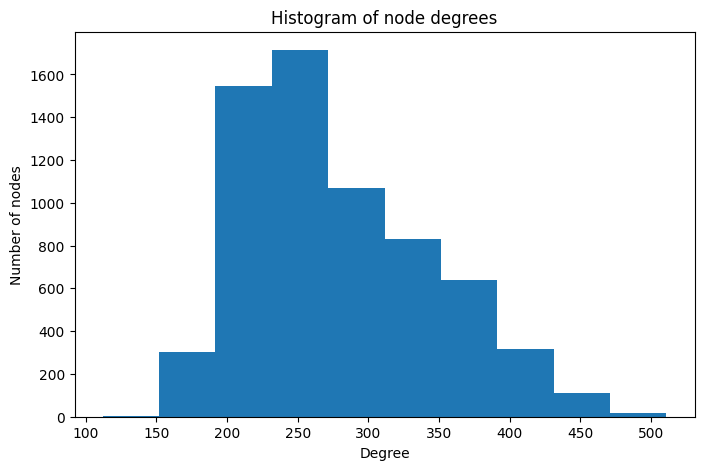

In [13]:
plt.figure(figsize=(8,5))
plt.hist(nb_edges)
plt.xlabel("Degree")
plt.ylabel("Number of nodes")
plt.title("Histogram of node degrees")
plt.show()

In [55]:
batch.edge_index.dtype

torch.int64

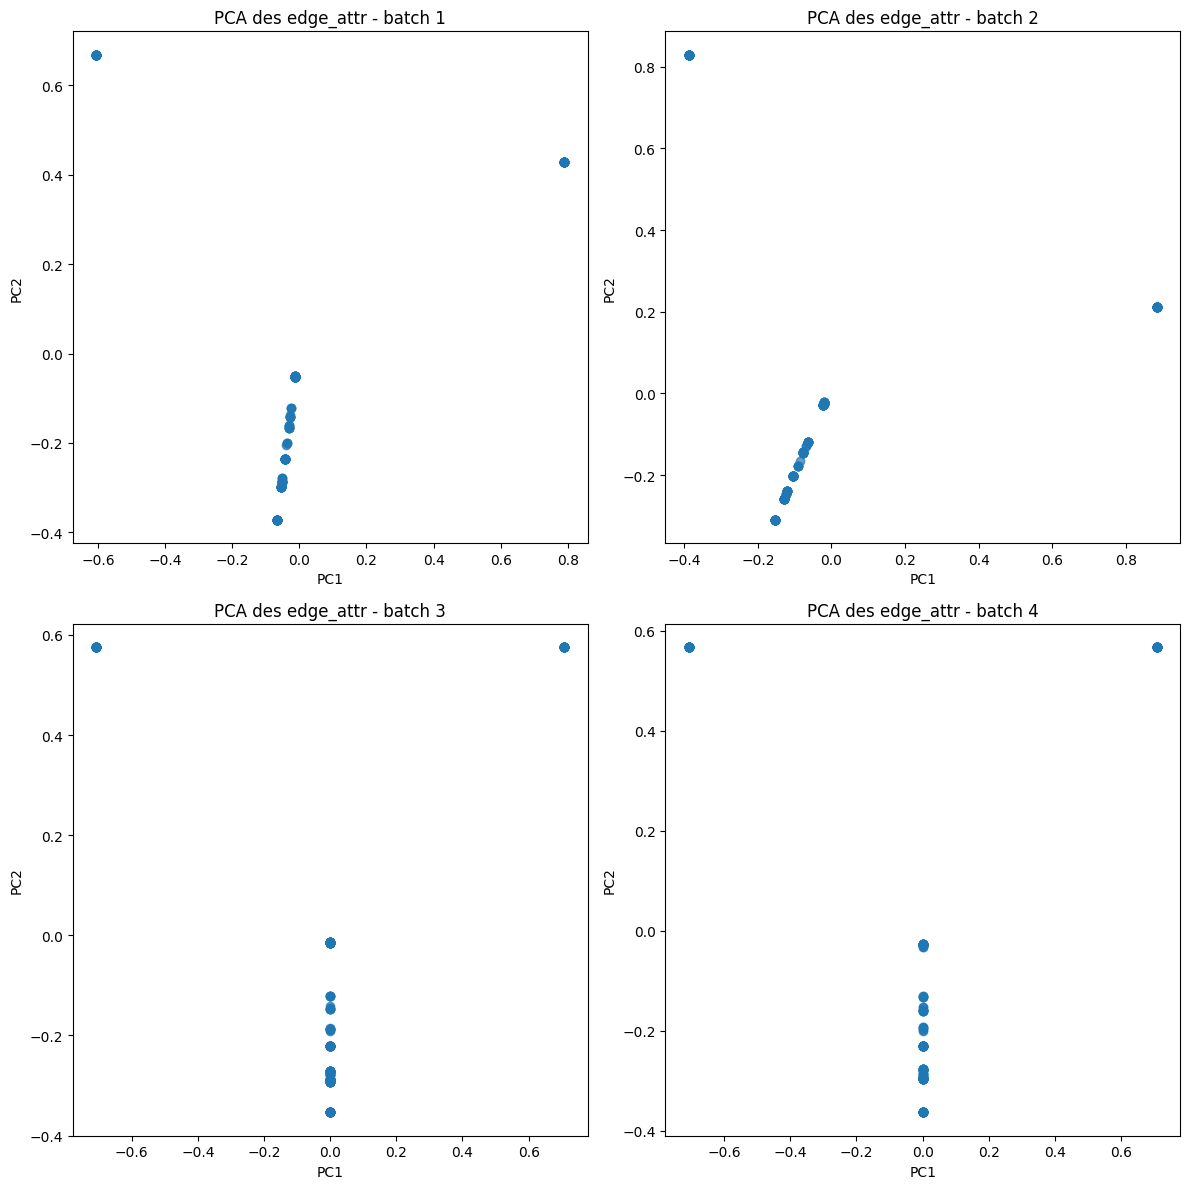

In [14]:
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
import torch

# On récupère les 4 premiers batchs
subgraphs = []
for batch in neighbor_loader:
    subgraphs.append(batch)
    if len(subgraphs) == 4:
        break

plt.figure(figsize=(12, 12))

for i, batch in enumerate(subgraphs):
    # edge_attr du batch
    edge_attr = batch.edge_attr  # shape [num_edges, num_features]

    if edge_attr is None or edge_attr.shape[0] == 0:
        print(f"Batch {i+1} n'a pas d'attributs d'arête")
        continue

    # Convertir en numpy
    X = edge_attr.detach().cpu().numpy()

    # PCA à 2 composantes
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    # Affichage
    plt.subplot(2, 2, i+1)
    plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.7)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"PCA des edge_attr - batch {i+1}")

plt.tight_layout()
plt.show()


apporte pas grand chose comme info : on sait que les graph ont a peu près les mêmes edges mais ce qui compte c'est les interactions

In [90]:
filepath = "../../data/pre_process/graph_construction/graph.pkl"
with open(filepath, 'rb') as f:
    graph = pickle.load(f)
graph

In [28]:
attack_nodes = [
    node for node, attr in graph.nodes(data=True)
    if "is_attack" in attr and int(attr["is_attack"]) > 0
]

benign_nodes = [
    node for node, attr in graph.nodes(data=True)
    if "is_attack" in attr and int(attr["is_attack"]) == 0
]

unknown_nodes = [
    node for node, attr in graph.nodes(data=True)
    if "is_attack" in attr and int(attr["is_attack"]) < 0
]

f"{len(attack_nodes)} attack nodes, {len(benign_nodes)} benign nodes, {len(unknown_nodes) } unknown nodes"

'0 attack nodes, 1041083 benign nodes, 6160 unknown nodes'

In [35]:
from enum import Enum

labels = [
    node for node, attr in graph.nodes(data=True)
    if attr["label"]
]

class NodeType(Enum):
    CENTRAL = 1
    PARAMETER = 2

not_central_and_not_label = [
    node for node, attr in graph.nodes(data=True)
    if attr["node_type"] != NodeType.CENTRAL.value and not attr["label"]
]

f"{len(labels)} total labeled nodes, {len(not_central_and_not_label)} non-central unlabeled nodes"

'296729 total labeled nodes, 0 non-central unlabeled nodes'

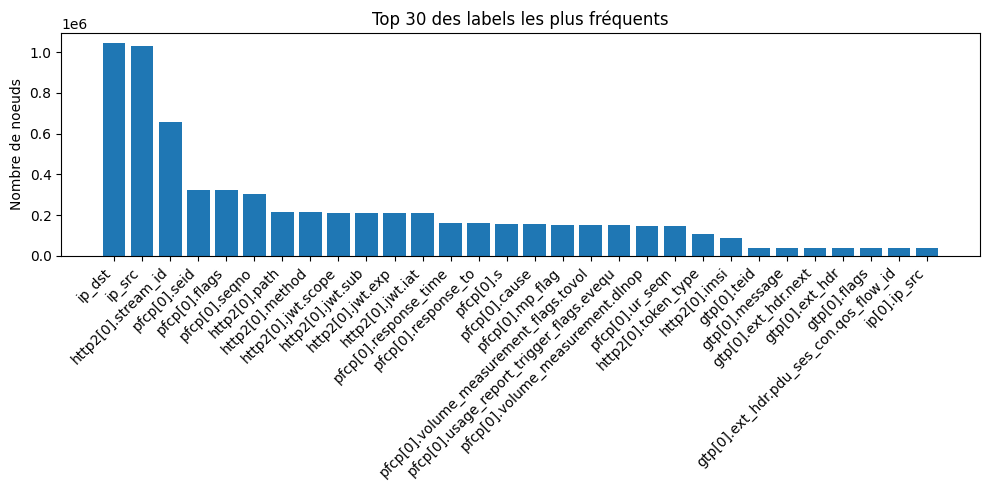

In [42]:
label_dict = {}
for u,v, attr in graph.edges(data=True):
    if attr["label"]:
        label = attr["label"]
        if label not in label_dict:
            label_dict[label] = 0
        label_dict[label] += 1

nb_top = 30
top = sorted(label_dict.items(), key=lambda x: x[1], reverse=True)[:nb_top]

# Plot
plt.figure(figsize=(10, 5))
plt.bar([x[0] for x in top], [x[1] for x in top])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Nombre de noeuds")
plt.title(f"Top {nb_top} des edge les plus fréquents")
plt.tight_layout()
plt.show()

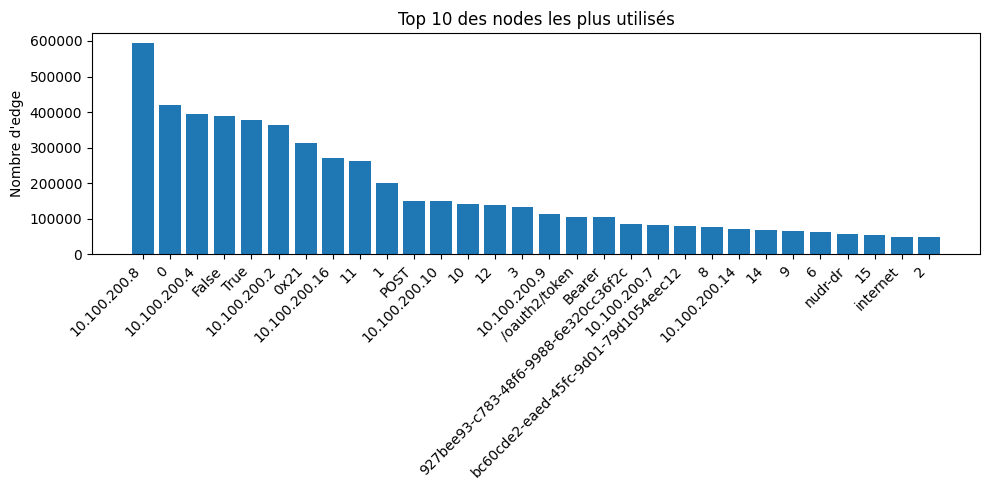

In [56]:
node_dict={}
for node, attr in graph.nodes(data=True):
    if "label" in attr and attr["label"]:
        node_dict[attr["label"]] = graph.degree(node)


nb_top = 30
top = sorted(node_dict.items(), key=lambda x: x[1], reverse=True)[:nb_top]

# Plot
plt.figure(figsize=(10, 5))
plt.bar([x[0] for x in top], [x[1] for x in top])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Nombre d'edge")
plt.title("Top 10 des nodes les plus utilisés")
plt.tight_layout()
plt.show()

In [92]:
filepath = "../../data/pre_process/graph_construction/graph.pkl"
with open(filepath, 'rb') as f:
    graph = pickle.load(f)
graph

In [95]:
all_types = []
for node, attr in graph.nodes(data=True):
    if 'type' in attr and attr['type'] not in all_types:
        all_types.append(attr['type'])
all_types

['register_random_ue',
 'add_random_nf',
 'restart',
 'deregister_random_ue',
 'cn_mitm',
 'set_random_ue_idle',
 'uplink_wake_random_u',
 'remove_random_nf',
 'user_traffic',
 'unknown',
 'uplink_spoofing',
 'flood_etablishment',
 'pfcp_in_gtp',
 'seid_fuzzing',
 'applicative_scan',
 'fuzz',
 'downlink_wake_random',
 'modify_drop',
 'modify_dupl',
 'flood_deletion']

In [96]:
all_types.index('fuzz')

15